Total images found: 47770


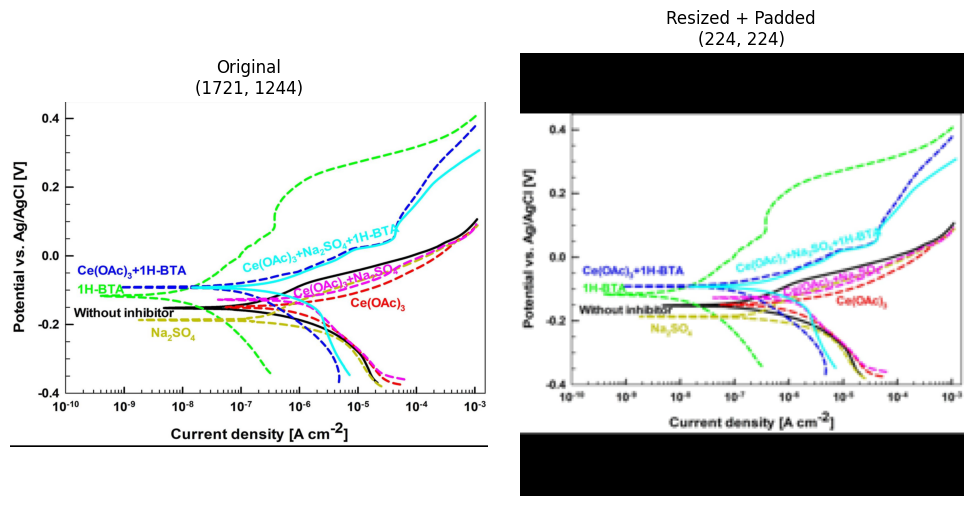

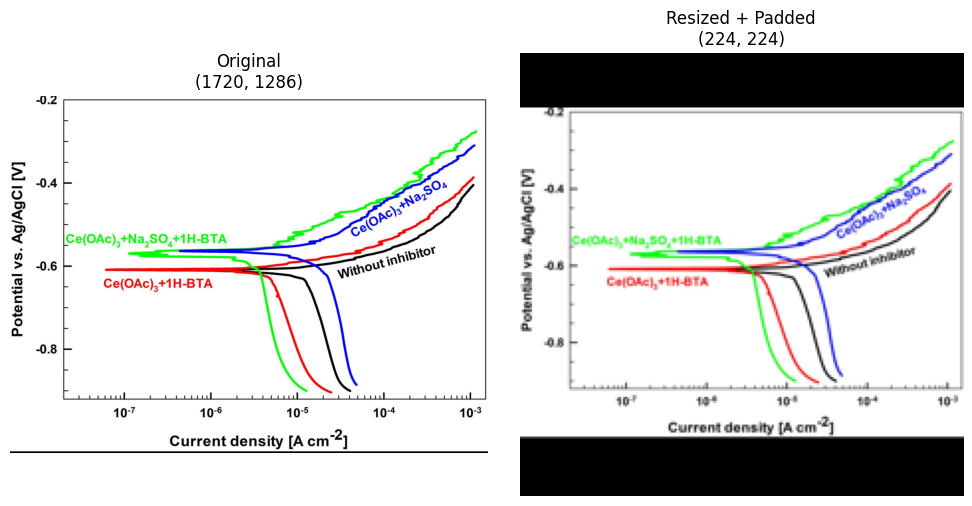

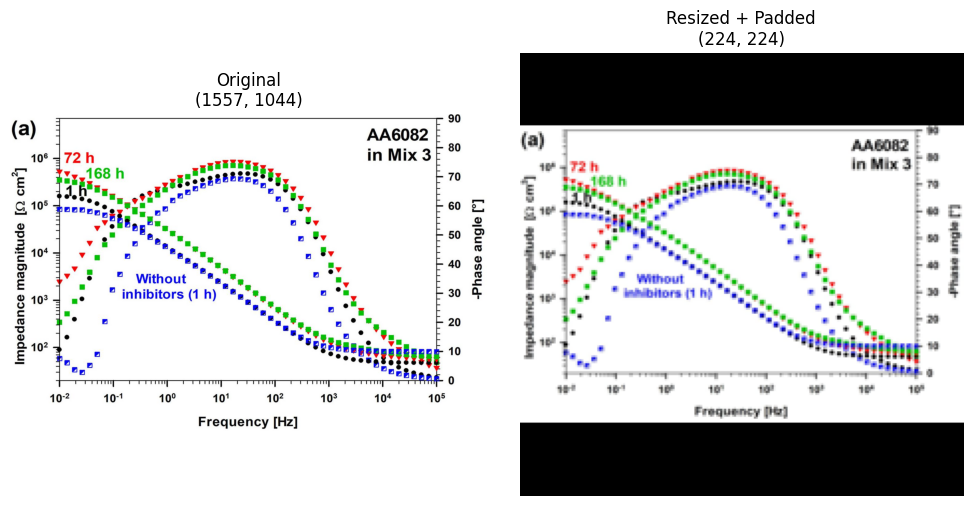

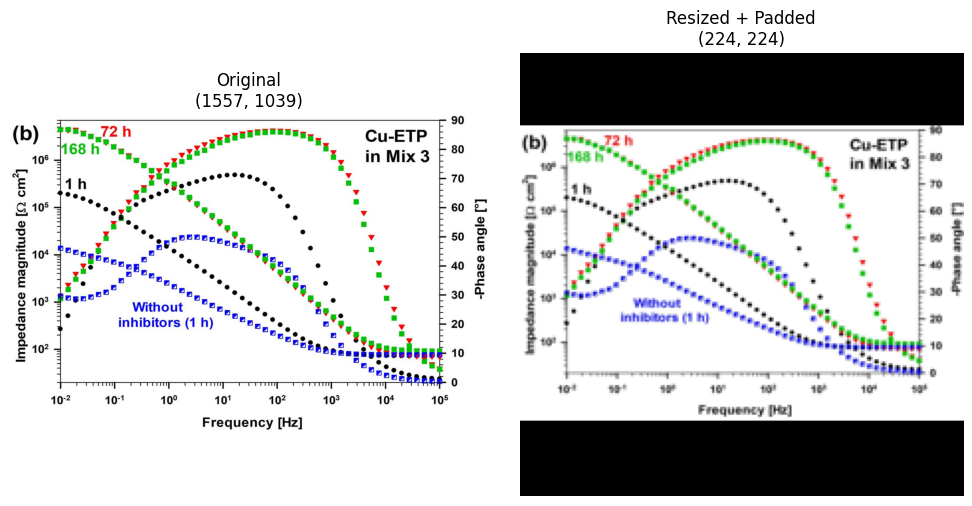

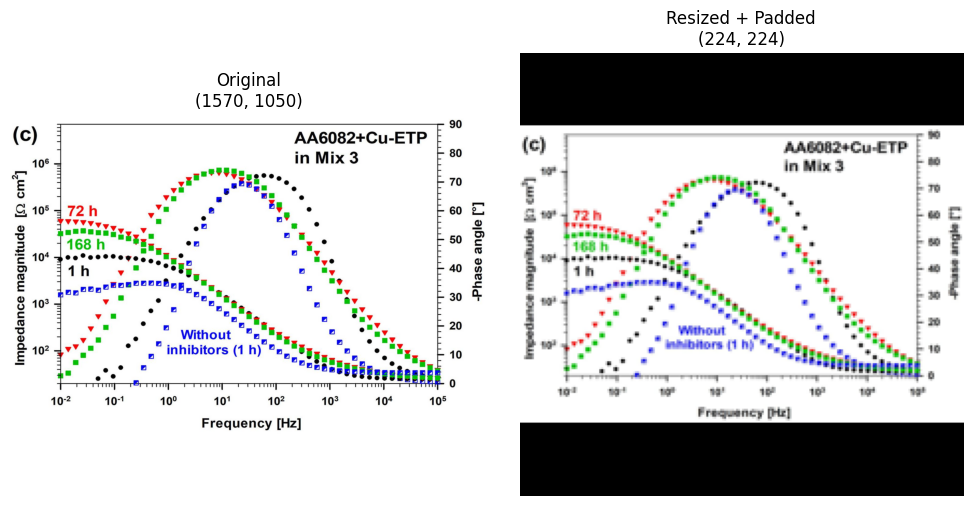


Starting batch resizing...



100%|██████████| 47770/47770 [10:35<00:00, 75.22it/s] 



All images resized successfully!

Total resized images: 47770


In [1]:
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# =========================================================
# CONFIGURATION
# =========================================================

# input image folder
RAW_DIR = Path("../data/raw")

# output resized folder
OUTPUT_DIR = Path("../data/resized")

# create output folder
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# target size for EfficientNet-B0
TARGET_SIZE = (224, 224)

# valid image extensions
VALID_EXTENSIONS = [
    ".png",
    ".jpg",
    ".jpeg",
    ".tif",
    ".bmp"
]

# =========================================================
# RESIZE + PADDING FUNCTION
# =========================================================

def resize_with_padding(
    img,
    target_size=(224, 224),
    background_color=(0, 0, 0)
):
    """
    Resize image while preserving aspect ratio,
    then pad to target size.
    """

    # create copy
    img = img.copy()

    # preserve aspect ratio
    img.thumbnail(target_size)

    # create new padded image
    new_img = Image.new(
        "RGB",
        target_size,
        background_color
    )

    # compute center position
    left = (target_size[0] - img.width) // 2
    top = (target_size[1] - img.height) // 2

    # paste resized image
    new_img.paste(img, (left, top))

    return new_img

# =========================================================
# COLLECT IMAGE PATHS
# =========================================================

image_paths = [
    p for p in RAW_DIR.glob("**/*")
    if p.suffix.lower() in VALID_EXTENSIONS
]

print(f"Total images found: {len(image_paths)}")

# =========================================================
# VISUAL TESTING ON FEW IMAGES
# =========================================================

sample_paths = image_paths[:5]

for path in sample_paths:

    try:

        # open image
        img = Image.open(path).convert("RGB")

        # resize
        resized = resize_with_padding(
            img,
            target_size=TARGET_SIZE
        )

        # show before and after
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))

        axes[0].imshow(img)
        axes[0].set_title(
            f"Original\n{img.size}"
        )
        axes[0].axis("off")

        axes[1].imshow(resized)
        axes[1].set_title(
            f"Resized + Padded\n{resized.size}"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    except Exception as e:

        print(f"Error with {path}: {e}")

# =========================================================
# BATCH RESIZE ALL IMAGES
# =========================================================

print("\nStarting batch resizing...\n")

for path in tqdm(image_paths):

    try:

        # open image
        img = Image.open(path).convert("RGB")

        # resize with padding
        resized = resize_with_padding(
            img,
            target_size=TARGET_SIZE
        )

        # preserve folder structure
        relative_path = path.relative_to(RAW_DIR)

        output_path = OUTPUT_DIR / relative_path

        # create parent folders
        output_path.parent.mkdir(
            parents=True,
            exist_ok=True
        )

        # save image
        resized.save(output_path)

    except Exception as e:

        print(f"Error processing {path}: {e}")

print("\nAll images resized successfully!")

# =========================================================
# VERIFY OUTPUT
# =========================================================

resized_images = list(
    OUTPUT_DIR.glob("**/*")
)

print(
    f"\nTotal resized images: "
    f"{len(resized_images)}"
)